# Tech Challenge - Fase 2: Otimização Genética e Interpretação de Diagnósticos com LLM
Este projeto evolui a base do sistema de IA do hospital universitário, utilizando Algoritmos Genéticos para a otimização de hiperparâmetros e Modelos de Linguagem de Grande Escala (LLM) para a interpretação humanizada dos resultados. O objetivo é elevar a precisão clínica e fornecer insights acionáveis para a equipe médica

**Tarefas Principais**: Otimização evolutiva de modelos de ML, monitoramento via MLflow e geração de diagnósticos explicáveis via IA Generativa

## 1. Imports necessários

In [0]:
%pip install -q openai
%pip install -q python-dotenv

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## 2. Carregando os dados da tabela gold

In [0]:
df_spark = sql('SELECT * FROM kevin_catalog.gold.tb_saude_mental')
display(df_spark.limit(10))

age,gender,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk,dummy_Employed,dummy_Self-employed,dummy_Student,dummy_Unemployed,dummy_Hybrid,dummy_On-site,dummy_Remote
56,0,1,1,6,6.2,3,28,17,54,59.7,1,true,false,false,false,false,true,false
46,1,0,1,10,9.0,4,30,11,85,54.9,1,false,false,true,false,false,true,false
32,1,1,0,7,7.7,2,24,7,62,61.3,1,true,false,false,false,false,true,false
25,1,1,1,3,5.4,0,24,12,70,69.0,1,false,true,false,false,false,true,false
38,1,1,1,3,9.9,3,17,9,63,69.3,1,false,false,false,true,false,true,false
36,0,0,0,8,7.1,5,25,8,72,58.4,1,false,false,true,false,false,false,true
40,0,0,0,7,6.5,6,28,6,46,60.4,1,true,false,false,false,true,false,false
28,1,0,0,8,3.1,0,7,18,88,93.2,1,true,false,false,false,false,false,true
28,1,1,0,6,9.7,2,14,9,85,71.2,1,false,true,false,false,false,true,false
41,1,1,0,10,4.4,7,13,2,23,80.1,1,false,true,false,false,false,true,false


In [0]:
# Conversão para Pandas para facilitar a análise exploratória
df_pd = df_spark.toPandas()

## 3. Exploração dos Dados
Nesta fase, carregamos os dados em Pandas para análise estatística e visualização.

<Axes: >

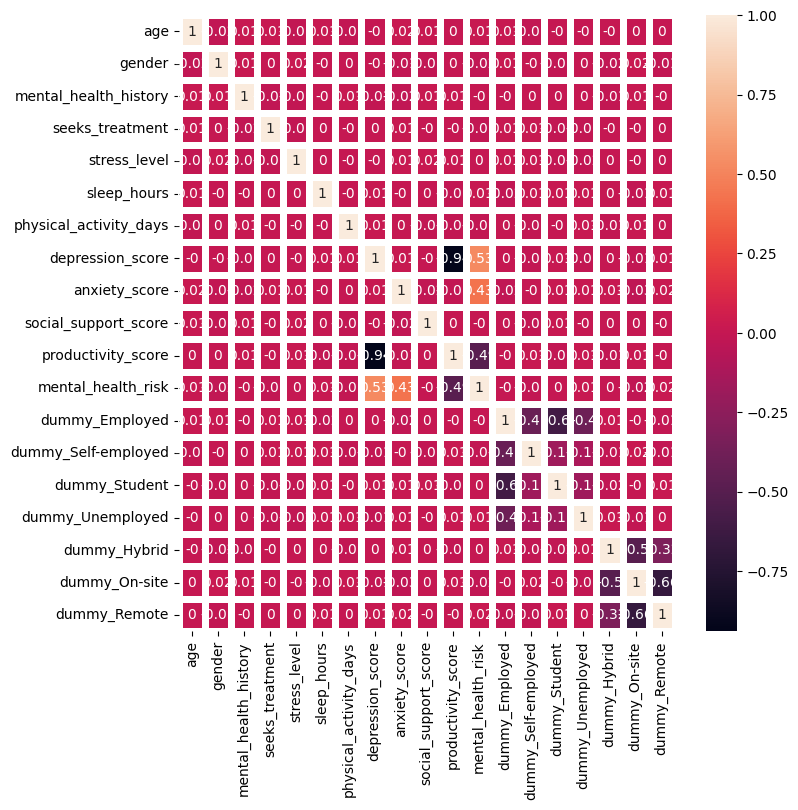

In [0]:
import matplotlib.pyplot as plt
import seaborn as sb

# Matriz de correlação para identificar variáveis que impactam o diagnóstico
corr_matriz = df_pd.corr().round(2)
fog, ax = plt.subplots(figsize=(8,8))
sb.heatmap(data=corr_matriz, annot=True, linewidths=5, ax=ax)

Interpretação: Observamos as correlações fortes entre as variáveis 
mental_health_risk x depression_score e mental_health_risk x anxiety_score, 
indicando que estas possuem comportamento conjunto relevante para o modelo. 

## 4. Pré-processamento
Preparamos os dados separando as características (X) do alvo (y) e realizando o escalonamento.

In [0]:
from sklearn.model_selection import *
from sklearn.model_selection import train_test_split

In [0]:
# Seleção das variáveis preditoras
x = df_pd[
    [
        "age",
        "gender",
        "mental_health_history",
        "seeks_treatment",
        "stress_level",
        "sleep_hours",
        "physical_activity_days",
        "depression_score",
        "anxiety_score",
        "social_support_score",
        "productivity_score",
        "dummy_Employed", 
        "dummy_Self-employed", 
        "dummy_Student", 
        "dummy_Unemployed",
        "dummy_Hybrid", 
        "dummy_On-site", 
        "dummy_Remote"
    ]
]

In [0]:
# Seleção da variável alvo (diagnóstico)
y = df_pd['mental_health_risk']

### Separação de base de treinamento e teste

In [0]:
# tamanho da base de teste = 20%
# random_state = 42. 
# Distribuição aleatória dos dados para garantir que a distribuição de classes seja a mesma em ambos os conjuntos de treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)


In [0]:
# Padronização
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
scaler.fit(x_train)

x_train_escalonado = scaler.transform(x_train)
x_test_escalonado = scaler.transform(x_test)

## 5. Algoritmos Genéticos

In [0]:
import random
import numpy as np
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

def generate_initial_population(pop_size, algoritmo):
    # Esta função inicializa a diversidade genética necessária para o início do processo evolutivo.
    population = []
    
    # Random Forest: Otimiza estimadores, profundidade e divisões
    if algoritmo == 'random_forest':
        for _ in range(pop_size):
            # Representação de genes como lista de inteiros para parâmetros do modelo
            individual = [
                random.randint(10, 500), # Gene 0: n_estimators (número de árvores)
                random.randint(2, 32),   # Gene 1: max_depth (profundidade da árvore)
                random.randint(2, 10)    # Gene 2: min_samples_split (critério de divisão)
            ]
            population.append(individual)
            
    # KNN: Otimiza o número de vizinhos e a métrica de distância 
    elif algoritmo == 'knn':
        for _ in range(pop_size):
            # Representação de genes adequada para os parâmetros do algoritmo KNN
            individual = [
                random.randint(1, 30), # Gene 0: n_neighbors (K vizinhos)
                random.randint(1, 2)   # Gene 1: p (1 para Manhattan, 2 para Euclidiana)
            ]
            population.append(individual)
            
    return population

def calculate_fitness(individual, x_train, y_train, x_test, y_test, algoritmo):
    # Esta função avalia a 'aptidão' de cada conjunto de hiperparâmetros para o diagnóstico médico.
    
    # modelo Random Forest com os genes (parâmetros) fornecidos 
    if algoritmo == 'random_forest':
        model = RandomForestClassifier(
            n_estimators=int(individual[0]),
            max_depth=int(individual[1]),
            min_samples_split=int(individual[2]),
            random_state=42
        )
        # O treinamento utiliza dados escalonados para garantir a eficácia do diagnóstico
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        
    # modelo KNN com os genes (parâmetros) fornecidos 
    elif algoritmo == 'knn':
        model = KNeighborsClassifier(
            n_neighbors=int(individual[0]),
            p=int(individual[1])
        )
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
    
    # Uso do F1-score para a função fitness.
    # O F1-score na classe 0 (Risco) é utilizado para equilibrar Precisão e Recall no diagnóstico.
    # Esta métrica guia o Algoritmo Genético para encontrar o modelo clínico mais equilibrado.
    return f1_score(y_test, preds, pos_label=0)

In [0]:
import mlflow
import mlflow.sklearn
import numpy as np
import random

def run_genetic_algorithm(pop_size, n_gen, mutation_prob, x_train, y_train, x_test, y_test, algoritmo_atual):
    """
    Executa o Algoritmo Genético para otimização de hiperparâmetro.
    Implementa monitoramento e logging para tracking de desempenho via mlflow.
    """
    
    # 1. Inicia o monitoramento 
    # O MLflow permite o tracking de desempenho.
    with mlflow.start_run(run_name=f"AG_{algoritmo_atual}_Fase2"):
        
        # Log de hiperparâmetros do AG para garantir reprodutibilidade dos experimentos 
        mlflow.log_param("pop_size", pop_size)
        mlflow.log_param("mutation_prob", mutation_prob)
        mlflow.log_param("algoritmo_alvo", algoritmo_atual)
        
        # Gera População Inicial
        # Os genes representam os hiperparâmetros específicos de cada modelo
        population = generate_initial_population(pop_size, algoritmo_atual)

        for gen in range(n_gen):
            # Avaliação de Aptidão
            # O fitness utiliza o F1-score para otimizar o diagnóstico de risco
            fitness_scores = [calculate_fitness(ind, x_train, y_train, x_test, y_test, algoritmo_atual) for ind in population]
            
            # Registro da métrica de desempenho por geração
            melhor_fitness_da_geracao = max(fitness_scores)
            mlflow.log_metric("f1_score_risk", melhor_fitness_da_geracao, step=gen)
            
            # Elitismo: Preserva o melhor gene para a próxima geração (Técnica de Otimização)
            best_idx = np.argmax(fitness_scores)
            new_population = [population[best_idx]] 

            # Loop para completar a nova população através de operadores genéticos 
            while len(new_population) < pop_size:
                
                # Operador de Seleção 
                # Escolha probabilística baseada na aptidão dos indivíduos.
                parents = random.choices(population, weights=fitness_scores, k=2)
                
                # Operador de Cruzamento
                # Aplica o Cruzamento Aritmético para combinar características dos pais.
                alpha = 0.5
                child = [int(p1 * alpha + p2 * (1 - alpha)) for p1, p2 in zip(parents[0], parents[1])]
                
                # Operador de Mutação
                # Introduz variação aleatória para explorar novas soluções no espaço de busca.
                if random.random() < mutation_prob:
                    # Mutação adaptada à codificação de cada algoritmo
                    if algoritmo_atual == 'random_forest':
                        child[0] = max(10, min(500, child[0] + random.randint(-20, 20))) # n_estimators
                        child[1] = max(2, min(32, child[1] + random.randint(-1, 1)))     # max_depth
                    elif algoritmo_atual == 'knn':
                        child[0] = max(1, min(30, child[0] + random.randint(-2, 2)))    # n_neighbors
                        child[1] = random.randint(1, 2)                                 # p (distância)
                
                new_population.append(child)
            
            population = new_population
            # Feedback visual para monitoramento em tempo real durante a execução
            print(f"[{algoritmo_atual}] Geração {gen}: Melhor Fitness = {melhor_fitness_da_geracao}")

        # 2. Log do Resultado Final
        # Identifica e salva os melhores hiperparâmetros encontrados após as gerações
        melhor_idx = np.argmax(fitness_scores)
        melhor_individuo = population[melhor_idx]
        
        # Logging dinâmico conforme o modelo otimizado
        if algoritmo_atual == 'random_forest':
            mlflow.log_params({
                "best_n_estimators": melhor_individuo[0],
                "best_max_depth": melhor_individuo[1],
                "best_min_samples_split": melhor_individuo[2]
            })
        else:
            mlflow.log_params({
                "best_n_neighbors": melhor_individuo[0],
                "best_p": melhor_individuo[1]
            })
            
    # Retorna o indivíduo otimizado para a Integração com LLM (Requisito 3) 
    return melhor_individuo

#### Parâmetros para disparar o algoritmo genético

In [0]:
POP_SIZE = 10
N_GEN = 15
MUTATION_PROB = 0.4

### KNN

In [0]:
# 1. Configuração inicial do experimento
ALGORITMO_ATUAL = 'knn'

melhor_individuo = run_genetic_algorithm(POP_SIZE, N_GEN, MUTATION_PROB, x_train_escalonado, y_train, x_test_escalonado, y_test, ALGORITMO_ATUAL)
    
print(f"Resultado Final AG: Melhor K encontrado foi {melhor_individuo[0]}")

[knn] Geração 0: Melhor Fitness = 0.7732463295269169
[knn] Geração 1: Melhor Fitness = 0.7732463295269169
[knn] Geração 2: Melhor Fitness = 0.7732463295269169
[knn] Geração 3: Melhor Fitness = 0.7732463295269169
[knn] Geração 4: Melhor Fitness = 0.7732463295269169
[knn] Geração 5: Melhor Fitness = 0.7732463295269169
[knn] Geração 6: Melhor Fitness = 0.7732463295269169
[knn] Geração 7: Melhor Fitness = 0.7732463295269169
[knn] Geração 8: Melhor Fitness = 0.7732463295269169
[knn] Geração 9: Melhor Fitness = 0.7732463295269169
[knn] Geração 10: Melhor Fitness = 0.7732463295269169
[knn] Geração 11: Melhor Fitness = 0.7732463295269169
[knn] Geração 12: Melhor Fitness = 0.7732463295269169
[knn] Geração 13: Melhor Fitness = 0.7732463295269169
[knn] Geração 14: Melhor Fitness = 0.7732463295269169
Resultado Final AG: Melhor K encontrado foi 6


In [0]:
print(f"Resultado Final AG: Melhor parâmetro (n_neighbors) encontrado foi {melhor_individuo[0]}")
print(f"Resultado Final AG: Melhor parâmetro (best_p) encontrado foi {melhor_individuo[0]}")


Resultado Final AG: Melhor parâmetro (n_neighbors) encontrado foi 6
Resultado Final AG: Melhor parâmetro (best_p) encontrado foi 6


In [0]:
# Treinamento final com os melhores parâmetros encontrados pelo AG
modelo_knn_otimizado = KNeighborsClassifier(
    n_neighbors=int(melhor_individuo[0]), 
    p=int(melhor_individuo[1])
)
modelo_knn_otimizado.fit(x_train_escalonado, y_train)

KNeighborsClassifier(n_neighbors=6, p=1)

#### Avaliação e Interpretação

In [0]:
# Predição com os dados de teste
y_predict_knn = modelo_knn_otimizado.predict(x_test_escalonado)

In [0]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(y_test, y_predict_knn))

0.922906267332224


In [0]:
print("--- Relatório de Classificação KNN Otimizado ---")
print(classification_report(y_test, y_predict_knn))

--- Relatório de Classificação KNN Otimizado ---
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       314
           1       0.95      0.96      0.95      1489

    accuracy                           0.92      1803
   macro avg       0.87      0.86      0.86      1803
weighted avg       0.92      0.92      0.92      1803



###  RANDOM FOREST

In [0]:
# 1. Configuração inicial do experimento
ALGORITMO_ATUAL = 'random_forest'

melhor_individuo = run_genetic_algorithm(POP_SIZE, N_GEN, MUTATION_PROB, x_train_escalonado, y_train, x_test_escalonado, y_test, ALGORITMO_ATUAL)
    
print(f"Resultado Final AG: Melhor parâmetro (n_estimators) encontrado foi {melhor_individuo[0]}")

[random_forest] Geração 0: Melhor Fitness = 0.9692058346839546
[random_forest] Geração 1: Melhor Fitness = 0.9692058346839546
[random_forest] Geração 2: Melhor Fitness = 0.9692058346839546
[random_forest] Geração 3: Melhor Fitness = 0.9692058346839546
[random_forest] Geração 4: Melhor Fitness = 0.9692058346839546
[random_forest] Geração 5: Melhor Fitness = 0.9692058346839546
[random_forest] Geração 6: Melhor Fitness = 0.9692058346839546
[random_forest] Geração 7: Melhor Fitness = 0.9692058346839546
[random_forest] Geração 8: Melhor Fitness = 0.9707792207792207
[random_forest] Geração 9: Melhor Fitness = 0.9707792207792207
[random_forest] Geração 10: Melhor Fitness = 0.9707792207792207
[random_forest] Geração 11: Melhor Fitness = 0.9707792207792207
[random_forest] Geração 12: Melhor Fitness = 0.9707792207792207
[random_forest] Geração 13: Melhor Fitness = 0.9707792207792207
[random_forest] Geração 14: Melhor Fitness = 0.9707792207792207
Resultado Final AG: Melhor parâmetro (n_estimators

In [0]:
print(f"Resultado Final AG: Melhor parâmetro (n_estimators) encontrado foi {melhor_individuo[0]}")
print(f"Resultado Final AG: Melhor parâmetro (max_depth) encontrado foi {melhor_individuo[1]}")
print(f"Resultado Final AG: Melhor parâmetro min_samples_split encontrado foi {melhor_individuo[2]}")

Resultado Final AG: Melhor parâmetro (n_estimators) encontrado foi 194
Resultado Final AG: Melhor parâmetro (max_depth) encontrado foi 17
Resultado Final AG: Melhor parâmetro min_samples_split encontrado foi 3


In [0]:
# Treinamento final com os melhores parâmetros encontrados pelo AG
modelo_rf_otimizado = RandomForestClassifier(
    n_estimators=int(melhor_individuo[0]), 
    max_depth=int(melhor_individuo[1]),
    min_samples_split=int(melhor_individuo[2]),
    random_state=42
)
modelo_rf_otimizado.fit(x_train_escalonado, y_train)

RandomForestClassifier(max_depth=17, min_samples_split=3, n_estimators=194,
                       random_state=42)

#### Avaliação e Interpretação

In [0]:
# Predição com os dados de teste
y_predict_rf = modelo_rf_otimizado.predict(x_test_escalonado)

In [0]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_predict_rf))

0.9900166389351082


In [0]:
# Avaliação do desempenho
print("--- Relatório de Classificação: Random Forest Otimizado ---")
print(classification_report(y_test, y_predict_rf))

--- Relatório de Classificação: Random Forest Otimizado ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       314
           1       0.99      1.00      0.99      1489

    accuracy                           0.99      1803
   macro avg       0.99      0.98      0.98      1803
weighted avg       0.99      0.99      0.99      1803



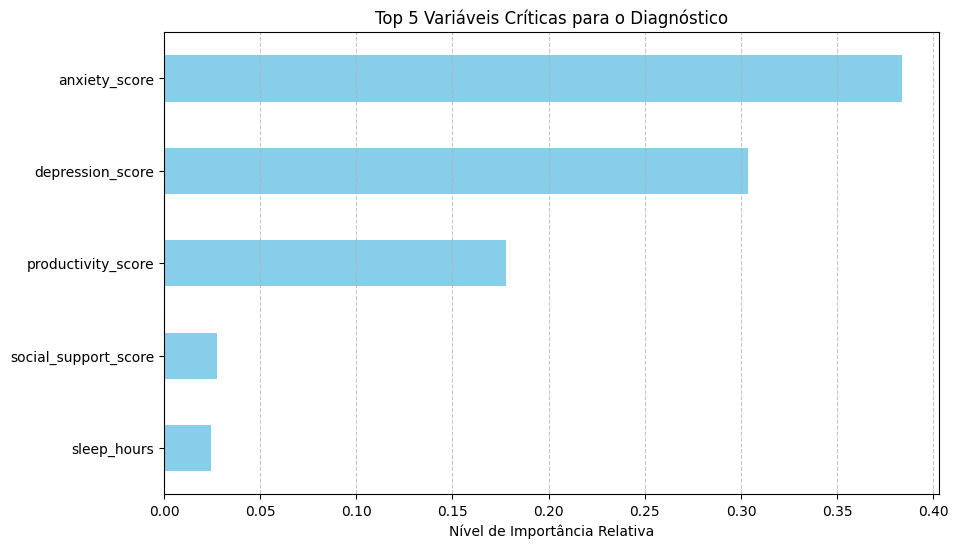

As 5 variáveis que mais influenciam o modelo são:
['anxiety_score', 'depression_score', 'productivity_score', 'social_support_score', 'sleep_hours']


In [0]:
# 1. Pegando as 5 variáveis com maior impacto no diagnóstico
import pandas as pd
importancias = pd.Series(modelo_rf_otimizado.feature_importances_, index=x.columns)
top_5_importancias = importancias.nlargest(5).sort_values(ascending=True)

# 2. Plotando o gráfico focado apenas no que importa para o médico
plt.figure(figsize=(10,6))
top_5_importancias.plot(kind='barh', color='skyblue')

plt.title("Top 5 Variáveis Críticas para o Diagnóstico")
plt.xlabel("Nível de Importância Relativa")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 3. Exibindo os nomes para conferência
print("As 5 variáveis que mais influenciam o modelo são:")
print(top_5_importancias.sort_values(ascending=False).index.tolist())

## 6. Integração da previsão de diagnóstico com ChatGPT

In [0]:
# Pegamos os dados de um paciente e a predição do seu modelo otimizado
paciente_exemplo = x_test.iloc[5].to_dict()
predicao = modelo_rf_otimizado.predict(x_test_escalonado[0].reshape(1, -1))[0]

print(f"Resultado do modelo: {predicao}")

# Traduzindo o código numérico conforme definido no Módulo 1 
if predicao == 0:
    # Classe 0 representa o grupo 'Low Risk'
    print("Interpretação: Baixo Risco (Baixo)")
else:
    # Classe 1 representa 'Medium/High Risk'
    print("Interpretação: Risco Detectado (Moderado/Alto)")

Resultado do modelo: 1
Interpretação: Risco Detectado (Moderado/Alto)


In [0]:
print(paciente_exemplo) # Visualização dos dados de entrada para o LLM

{'age': 28, 'gender': 0, 'mental_health_history': 1, 'seeks_treatment': 1, 'stress_level': 7, 'sleep_hours': 5.1, 'physical_activity_days': 3, 'depression_score': 16, 'anxiety_score': 4, 'social_support_score': 57, 'productivity_score': 79.0, 'dummy_Employed': True, 'dummy_Self-employed': False, 'dummy_Student': False, 'dummy_Unemployed': False, 'dummy_Hybrid': False, 'dummy_On-site': False, 'dummy_Remote': True}


In [0]:
def criar_prompt_medico(dados, resultado):
    status = "Baixo Risco" if resultado == 0 else "Risco Detectado (Moderado/Alto)"
    
    prompt = f"""
    Aja como um assistente de diagnóstico psiquiátrico clínico. 
    O modelo de IA foi treinado para identificar pacientes com risco de desenvolver transtornos mentais e precisa de orientação clínica.
    A partir dos dados abaixo, você precisa fornecer uma explicação clínica detalhada e uma recomendação de conduta imediata para o médico responsável.
    
    DADOS CLÍNICOS E SENSORIAIS:
    - Score de Ansiedade (0-21): {dados['anxiety_score']}
    - Score de Depressão (0-21): {dados['depression_score']}
    - Score de Produtividade Percetida (0-100): {dados['productivity_score']}
    - Score de Suporte Social (0-100): {dados['social_support_score']}
    - Horas de Sono (Média): {dados['sleep_hours']}
    
    CLASSIFICAÇÃO DO MODELO IA: {status}
    
    Tarefa: 
    1. Converta esses dados estatísticos em uma explicação em linguagem natural para o médico responsável. 
    2. Transforme esses números em 3 insights clínicos acionáveis e recomendações de conduta imediata. 
    3. Explique por que, neste contexto específico, a correlação entre ansiedade, depressão e o impacto na produtividade e suporte social é relevante.
    """
    return prompt

In [0]:
meu_prompt = criar_prompt_medico(paciente_exemplo, predicao)

In [0]:
import os
from dotenv import load_dotenv
from openai import OpenAI

# Carrega as variáveis do arquivo .env
load_dotenv()

# Obtém a chave da OpenAI
client = OpenAI(api_key=os.getenv("CHAT_GPT_KEY"))

response = client.chat.completions.create(
    model="gpt-4o", # Modelo utilizado
    messages=[
        {"role": "user", "content": meu_prompt}
    ],
    max_completion_tokens=1000  # Limita a resposta a 100 tokens
)

# 4. Acessando o conteúdo da resposta
print(response.choices[0].message.content)

**Explicação Clínica em Linguagem Natural:**

Com base nos dados fornecidos, o paciente apresenta um baixo nível de ansiedade, com um score de 4 em uma escala que vai até 21, sugerindo que a ansiedade não é uma preocupação clínica significativa neste momento. No entanto, o score de depressão é notavelmente elevado, registrando 16 em 21, o que indica um quadro de depressão moderada a grave. Isso é corroborado por uma média de horas de sono de apenas 5.1 por noite, o que está abaixo do recomendado para adultos e pode agravar ou ser um sintoma da depressão.

A produtividade percebida do paciente é alta, com um score de 79 em 100, sugerindo que, apesar dos sintomas, o paciente consegue manter um nível elevado de produtividade. No entanto, o suporte social é moderado, com um score de 57 em 100, indicando que o paciente pode ter limitações no seu sistema de apoio social, o que pode ser um fator de risco ou um agravante para o estado depressivo.

**Insights Clínicos Acionáveis e Recomendações